# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [8]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('data/retailmax.csv')

# Verificar
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

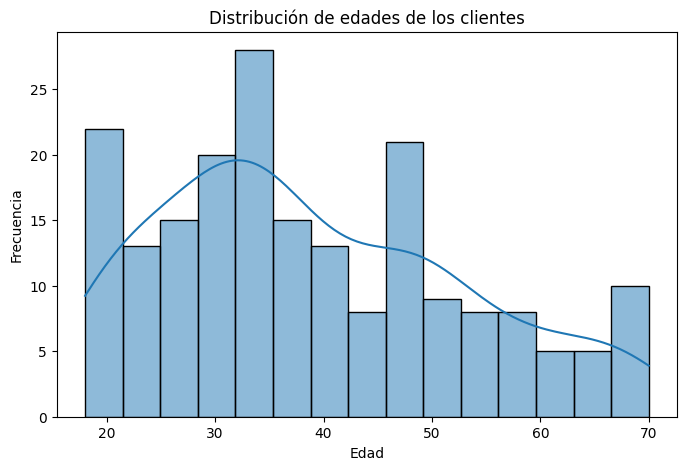

In [9]:
# Verificar primeras filas (opcional)
df.head()

# Histograma de la edad
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True)

plt.title('Distribución de edades de los clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

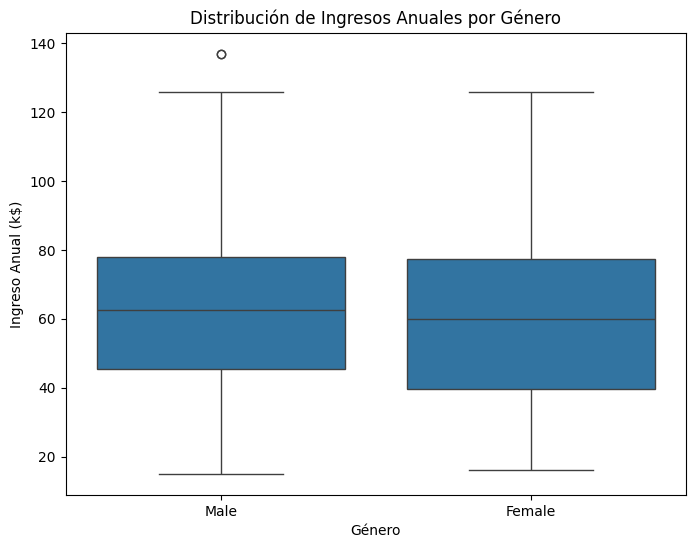

In [10]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Gender', y='Annual Income (k$)', data=df)

plt.title('Distribución de Ingresos Anuales por Género')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual (k$)')

plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

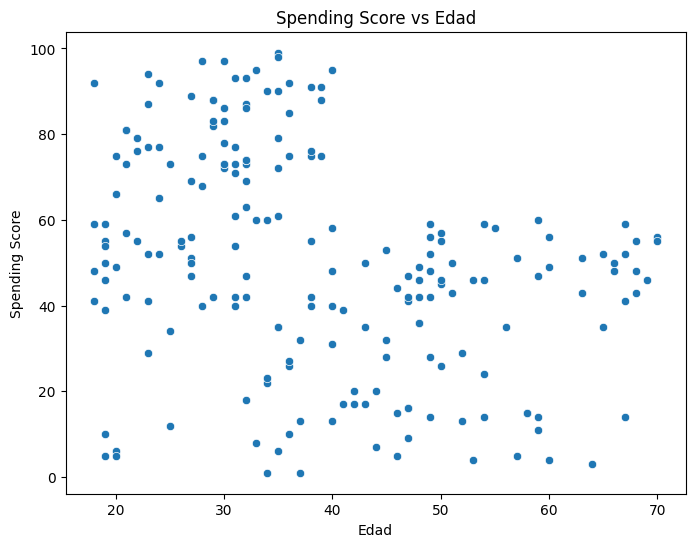

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df)

plt.title('Spending Score vs Edad')
plt.xlabel('Edad')
plt.ylabel('Spending Score')

plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

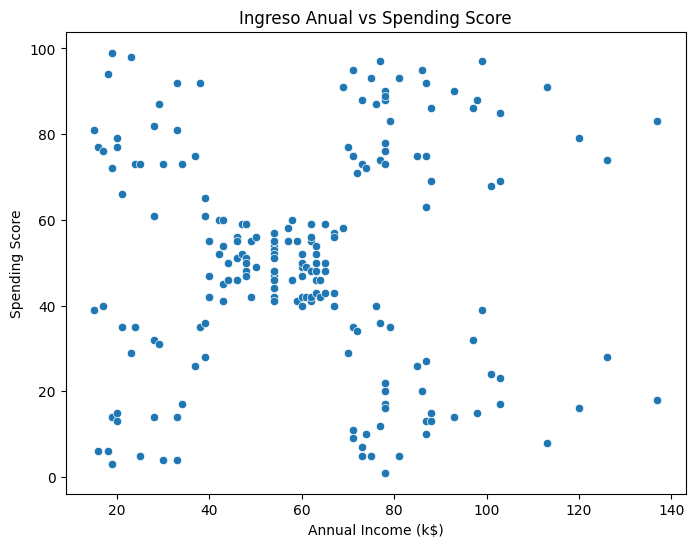

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)

plt.title('Ingreso Anual vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.show()

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

In [13]:
# Crear rangos de ingreso

df['Income Group'] = pd.cut(
    df['Annual Income (k$)'],
    bins=[0, 40, 70, 100, 140],
    labels=['Bajo', 'Medio', 'Alto', 'Muy Alto']
)

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

In [14]:
df['Gender'].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

In [15]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[0, 18, 25, 35, 45, 55, 100],
                       labels=['0-18', '19-25', '26-35', '36-45', '46-55', '56+'])

In [16]:
gasto_promedio = df.groupby('AgeGroup')['Spending Score (1-100)'].mean()

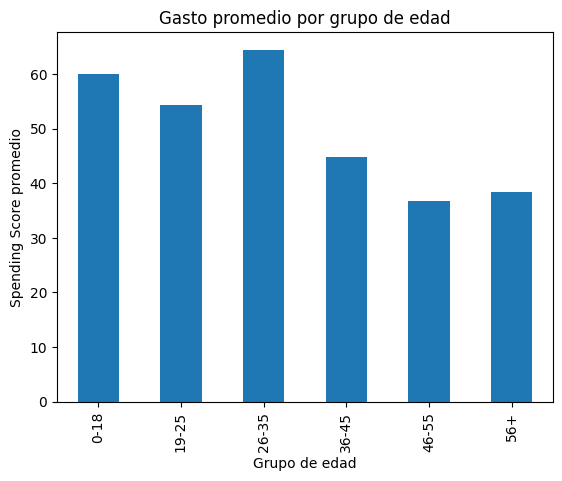

In [17]:
gasto_promedio.plot(kind='bar')

plt.title('Gasto promedio por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score promedio')
plt.show()

##Se agruparon los clientes por rangos de edad 
# y se calculó el promedio de la puntuación de gasto para cada grupo. 
# Esto permite identificar qué segmentos de edad tienen mayor tendencia a gastar.

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

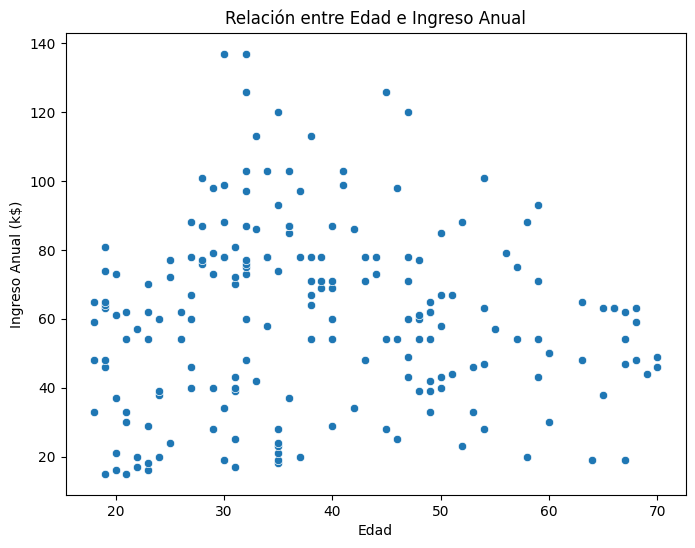

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Age', y='Annual Income (k$)', data=df)

plt.title('Relación entre Edad e Ingreso Anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso Anual (k$)')
plt.show()

##Se utilizó una gráfica de dispersión para analizar la relación entre la edad y el ingreso anual. 
# Esto permite observar si existe alguna tendencia o patrón entre ambas variables.

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

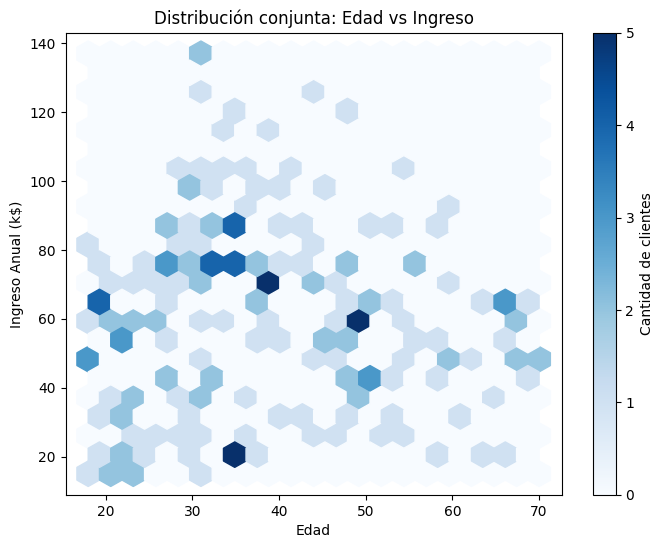

In [19]:
plt.figure(figsize=(8,6))

plt.hexbin(
    df['Age'],
    df['Annual Income (k$)'],
    gridsize=20,
    cmap='Blues'
)

plt.colorbar(label='Cantidad de clientes')
plt.xlabel('Edad')
plt.ylabel('Ingreso Anual (k$)')
plt.title('Distribución conjunta: Edad vs Ingreso')
plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

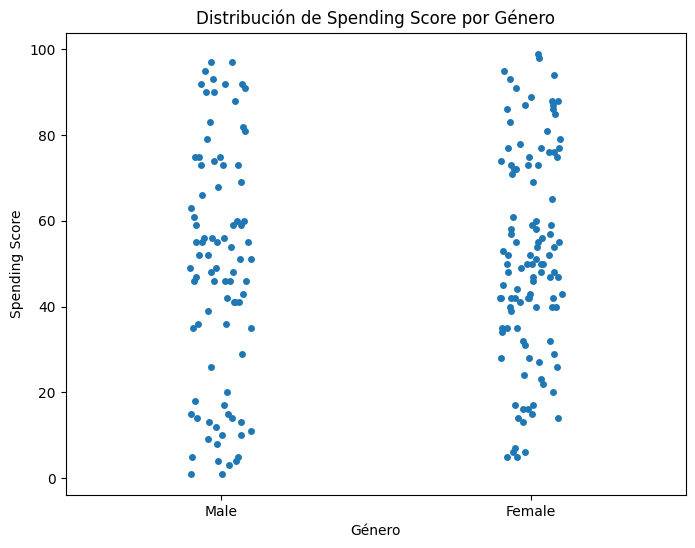

In [20]:
plt.figure(figsize=(8,6))

sns.stripplot(
    x='Gender',
    y='Spending Score (1-100)',
    data=df,
    jitter=True
)

plt.title('Distribución de Spending Score por Género')
plt.xlabel('Género')
plt.ylabel('Spending Score')
plt.show()